In [1]:
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn import svm
from sklearn import metrics
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
import lightgbm as lgb
from imblearn.under_sampling import RandomUnderSampler  


from matplotlib import pyplot as plt
import seaborn as sns

2026-04-03 21:24:36.234540: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-03 21:24:36.234837: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-03 21:24:36.271822: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-03 21:24:37.306450: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [2]:
#Load in data
x_train_bal = pd.read_parquet('X_train_balanced.parquet', engine='fastparquet')
y_train_bal = pd.read_parquet('Y_train_balanced.parquet', engine= 'fastparquet')
x_train = pd.read_parquet('X_train.parquet', engine= 'fastparquet')
y_train = pd.read_parquet('Y_train.parquet', engine= 'fastparquet')
x_val = pd.read_parquet('X_val.parquet', engine='fastparquet')
y_val = pd.read_parquet('Y_val.parquet', engine='fastparquet')
x_test = pd.read_parquet('X_test.parquet', engine='fastparquet')
y_test = pd.read_parquet('Y_test.parquet', engine='fastparquet')

In [3]:
#Load in unscaled datasets for minMax scaling later on
x_train_unscaled = pd.read_parquet('X_train_unscaled.parquet', engine='fastparquet')
x_val_unscaled = pd.read_parquet('X_val_unscaled.parquet', engine='fastparquet')
x_test_unscaled = pd.read_parquet('X_test_unscaled.parquet', engine='fastparquet')


In [4]:
#Create new binary label for testing depression symptoms vs no depression symptoms
y_train['depression_sign_binary'] = y_train['depression_severity'].map({0:0, 1:1, 2:1})
y_test['depression_sign_binary'] = y_test['depression_severity'].map({0:0, 1:1, 2:1})
y_val['depression_sign_binary'] = y_val['depression_severity'].map({0:0, 1:1, 2:1})
y_train_bal['depression_sign_binary'] = y_train_bal['depression_severity'].map({0:0, 1:1, 2:1})

In [5]:
#Create undersampled data from either multiclass or binary labels
under_sampler = RandomUnderSampler(random_state=0)
x_train_under, y_train_under = under_sampler.fit_resample(x_train, y_train['depression_severity'])
x_train_under_bin, y_train_under_bin = under_sampler.fit_resample(x_train, y_train['depression_sign_binary'])
print("Shape of the undersampled training data:",x_train_under.shape)
print("Shape of the undersampled binar training data:",x_train_under_bin.shape)


Shape of the undersampled training data: (816, 146)
Shape of the undersampled binar training data: (1566, 146)


# Logarithmic Regression

In [6]:
# columns_to_scale = []
# for col in x_train.columns:
#     if np.max(x_train[col]) > 1.0:
#         columns_to_scale.append(col)
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('scaler', StandardScaler(), columns_to_scale)
#     ],
#     remainder='passthrough'
# )
# # preprocessor.set_output(transform="pandas")

# x_train_std = preprocessor.fit(x_train).transform(x_train)
# x_val_std = preprocessor.fit(x_train).transform(x_val)
# x_test_std = preprocessor.fit(x_train).transform(x_test)

In [7]:
#logistic regression model for multiclass

def build_model_LG(num_features, learning_rate):
  """Build a TF linear regression model using Keras.

  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for SGD.

  Returns:
    model: A tf.keras model (graph).
  """
  # This is not strictly necessary, but each time you build a model, TF adds
  # new nodes (rather than overwriting), so the colab session can end up
  # storing lots of copies of the graph when you only care about the most
  # recent. Also, as there is some randomness built into training with SGD,
  # setting a random seed ensures that results are the same on each identical
  # training run.
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  # Build a model using keras.Sequential. While this is intended for neural
  # networks (which may have multiple layers), we want just a single layer for
  # binary logistic regression.
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=3,        # output dim
      input_shape=(num_features,),  # input dim
      use_bias=True,               # use a bias (intercept) param
      activation='softmax',
      kernel_initializer=tf.ones_initializer,  # initialize params to 1
      bias_initializer=tf.ones_initializer,    # initialize bias to 1
  ))
  # model.add(tf.keras.layers.Softmax(axis=1))
  # We need to choose an optimizer. We'll use SGD, which is actually mini-batch GD
  optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

  # Finally, compile the model. Select the accuracy metric (!!!). This finalizes the graph for training.
  model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'] 
    )
    
  return model

/home/jeff/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1775276680.823616  175397 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775276680.828580  175397 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Text(0.5, 1.0, 'Accuracy Change with Model Training')

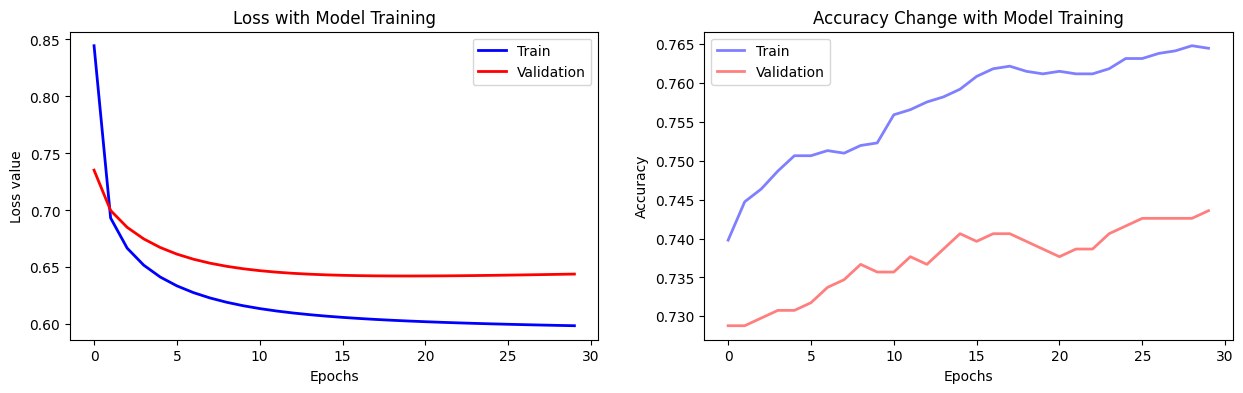

In [8]:
#Create logistic regression model with x_train data
tf.random.set_seed(0)
tf.keras.utils.set_random_seed(0)
class_weights = {0: 1., 1: 5., 2:7.}
# 2. Build and compile model
# YOUR CODE HERE
model_lg = build_model_LG(
        num_features=x_train.shape[1],
        learning_rate=0.001
    )
# 3. Fit the model
# YOUR CODE HERE
fit_lg = model_lg.fit(
      x = x_train,
      y = y_train['depression_severity'],
      epochs=30,
      batch_size=32,
      verbose=0,
      validation_data = (x_val, y_val['depression_severity']),
    #   class_weight=class_weights
      )

# 4. Generate (1,2) plot
history = fit_lg.history
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(history['loss'], lw=2, color='blue')
ax1.plot(history['val_loss'], lw=2, color='red')
ax1.legend(['Train', 'Validation'], fontsize=10)
ax1.set_xlabel('Epochs', size=10)
ax1.set_ylabel("Loss value")
ax1.set_title('Loss with Model Training')

ax2.plot(history['accuracy'], lw=2, color='blue', alpha = 0.5)
ax2.plot(history['val_accuracy'], lw=2, color='red', alpha = 0.5)
ax2.legend(['Train', 'Validation'], fontsize=10)
ax2.set_xlabel('Epochs', size=10)
ax2.set_ylabel("Accuracy")
ax2.set_title('Accuracy Change with Model Training')

In [9]:
#Create train and test predictions from x_train model and test recall
train_preds = model_lg.predict(x_train)
train_preds_labels = np.argmax(train_preds, axis=1)
train_accuracy = np.mean(y_train['depression_severity'] == train_preds_labels)
print(f'Train accuracy: {train_accuracy}')

test_preds = model_lg.predict(x_test)
test_preds_labels = np.argmax(test_preds, axis=1)
test_accuracy = np.mean(y_test['depression_severity'] == test_preds_labels)
print(f'Test accuracy: {test_accuracy}')
class_report = classification_report(y_test['depression_severity'], test_preds_labels, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "Logistic Regression"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train"
print(f'Classification report: \n {classification_report(y_test['depression_severity'], test_preds_labels)}')

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step
Train accuracy: 0.7654605263157894
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 871us/step
Test accuracy: 0.7652859960552268
Classification report: 
               precision    recall  f1-score   support

           0       0.81      0.96      0.88       776
           1       0.36      0.14      0.20       155
           2       0.31      0.12      0.17        83

    accuracy                           0.77      1014
   macro avg       0.49      0.41      0.42      1014
weighted avg       0.70      0.77      0.72      1014



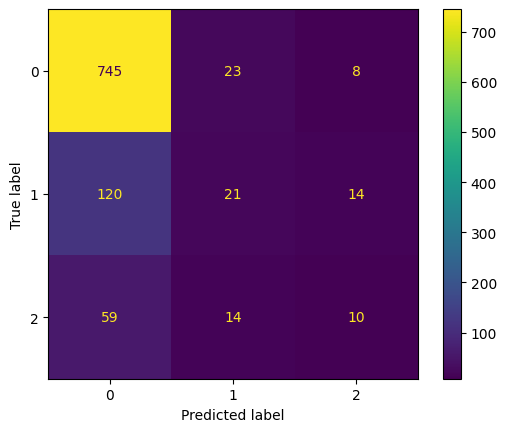

In [10]:
#Create confusion matrix from x_train LG model
cnf_matrix = confusion_matrix(np.array(y_test['depression_severity']), test_preds_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix)
disp.plot()

/home/jeff/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Text(0.5, 1.0, 'Accuracy Change with Model Training')

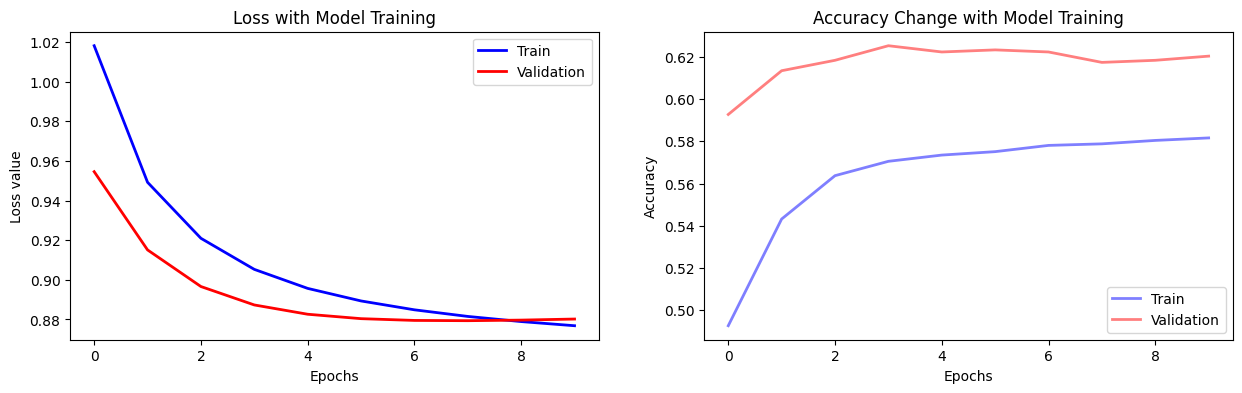

In [11]:
#Create LR model using x_train_bal (balanced) dataset
tf.random.set_seed(0)
tf.keras.utils.set_random_seed(0)
class_weights = {0: 1., 1: 5., 2:7.}
# 2. Build and compile model
# YOUR CODE HERE
model_lg = build_model_LG(
        num_features=x_train_bal.shape[1],
        learning_rate=0.001
    )
# 3. Fit the model
# YOUR CODE HERE
fit_lg = model_lg.fit(
      x = x_train_bal,
      y = y_train_bal['depression_severity'],
      epochs=10,
      batch_size=32,
      verbose=0,
      validation_data = (x_val, y_val['depression_severity']),
    #   class_weight=class_weights
      )

# 4. Generate (1,2) plot
history = fit_lg.history
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(history['loss'], lw=2, color='blue')
ax1.plot(history['val_loss'], lw=2, color='red')
ax1.legend(['Train', 'Validation'], fontsize=10)
ax1.set_xlabel('Epochs', size=10)
ax1.set_ylabel("Loss value")
ax1.set_title('Loss with Model Training')

ax2.plot(history['accuracy'], lw=2, color='blue', alpha = 0.5)
ax2.plot(history['val_accuracy'], lw=2, color='red', alpha = 0.5)
ax2.legend(['Train', 'Validation'], fontsize=10)
ax2.set_xlabel('Epochs', size=10)
ax2.set_ylabel("Accuracy")
ax2.set_title('Accuracy Change with Model Training')

In [12]:
#Create predictions from x_train_bal data and test recall
train_preds = model_lg.predict(x_train)
train_preds_labels = np.argmax(train_preds, axis=1)
train_accuracy = np.mean(y_train['depression_severity'] == train_preds_labels)
print(f'Train accuracy: {train_accuracy}')

test_preds = model_lg.predict(x_test)
test_preds_labels = np.argmax(test_preds, axis=1)
test_accuracy = np.mean(y_test['depression_severity'] == test_preds_labels)
class_report = classification_report(y_test['depression_severity'], test_preds_labels, output_dict=True)
df_report2 = pd.DataFrame(class_report).transpose()
df_report2['model'] = "Logistic Regression"
df_report2['classification'] = "Multi (3)"
df_report2['data_type'] = "x_train_bal"
df_report_final = pd.concat([df_report, df_report2])
print(f'Test accuracy: {test_accuracy}')

print(f'Classification report: \n {classification_report(y_test['depression_severity'], test_preds_labels)}')

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step
Train accuracy: 0.6358552631578948
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step
Test accuracy: 0.5936883629191322
Classification report: 
               precision    recall  f1-score   support

           0       0.88      0.67      0.76       776
           1       0.20      0.28      0.23       155
           2       0.20      0.48      0.28        83

    accuracy                           0.59      1014
   macro avg       0.42      0.48      0.42      1014
weighted avg       0.72      0.59      0.64      1014



/home/jeff/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Text(0.5, 1.0, 'Accuracy Change with Model Training')

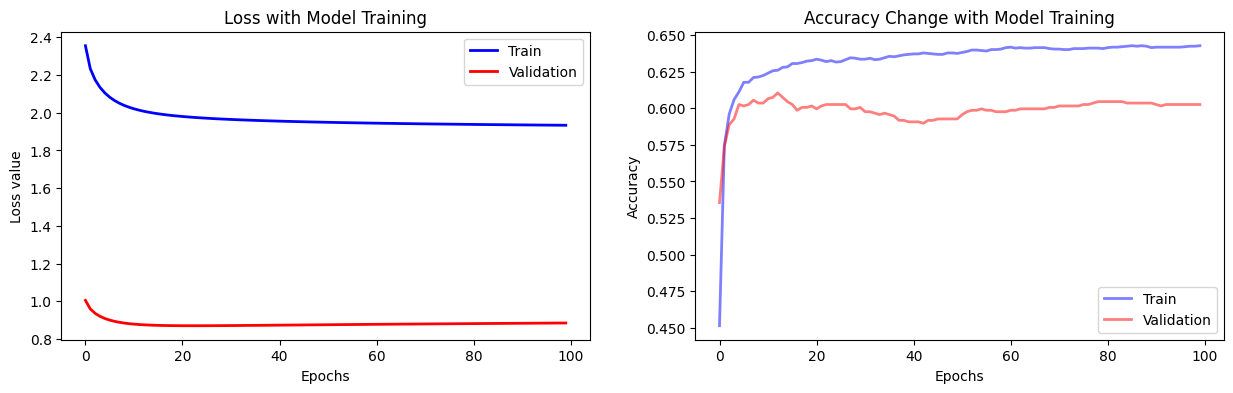

In [13]:
#Create LR model from x_train data with class weights
tf.random.set_seed(0)
tf.keras.utils.set_random_seed(0)
class_weights = {0: 1., 1: 5., 2:7.}
# 2. Build and compile model
# YOUR CODE HERE
model_lg = build_model_LG(
        num_features=x_train.shape[1],
        learning_rate=0.001
    )
# 3. Fit the model
# YOUR CODE HERE
fit_lg = model_lg.fit(
      x = x_train,
      y = y_train['depression_severity'],
      epochs=100,
      batch_size=32,
      verbose=0,
      validation_data = (x_val, y_val['depression_severity']),
      class_weight=class_weights
      )

# 4. Generate (1,2) plot
history = fit_lg.history
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(history['loss'], lw=2, color='blue')
ax1.plot(history['val_loss'], lw=2, color='red')
ax1.legend(['Train', 'Validation'], fontsize=10)
ax1.set_xlabel('Epochs', size=10)
ax1.set_ylabel("Loss value")
ax1.set_title('Loss with Model Training')

ax2.plot(history['accuracy'], lw=2, color='blue', alpha = 0.5)
ax2.plot(history['val_accuracy'], lw=2, color='red', alpha = 0.5)
ax2.legend(['Train', 'Validation'], fontsize=10)
ax2.set_xlabel('Epochs', size=10)
ax2.set_ylabel("Accuracy")
ax2.set_title('Accuracy Change with Model Training')

In [14]:
#Create predictions from weighted x_train LR model to test recall
train_preds = model_lg.predict(x_train)
train_preds_labels = np.argmax(train_preds, axis=1)
train_accuracy = np.mean(y_train['depression_severity'] == train_preds_labels)
print(f'Train accuracy: {train_accuracy}')

test_preds = model_lg.predict(x_test)
test_preds_labels = np.argmax(test_preds, axis=1)
test_accuracy = np.mean(y_test['depression_severity'] == test_preds_labels)
print(f'Test accuracy: {test_accuracy}')

class_report = classification_report(y_test['depression_severity'], test_preds_labels, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "Logistic Regression"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train weighted"
df_report_final = pd.concat([df_report_final, df_report])

print(f'Classification report: \n {classification_report(y_test['depression_severity'], test_preds_labels)}')

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step
Train accuracy: 0.6457236842105263
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step
Test accuracy: 0.5907297830374754
Classification report: 
               precision    recall  f1-score   support

           0       0.89      0.65      0.75       776
           1       0.22      0.43      0.29       155
           2       0.21      0.36      0.26        83

    accuracy                           0.59      1014
   macro avg       0.44      0.48      0.43      1014
weighted avg       0.73      0.59      0.64      1014



/home/jeff/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Text(0.5, 1.0, 'Accuracy Change with Model Training')

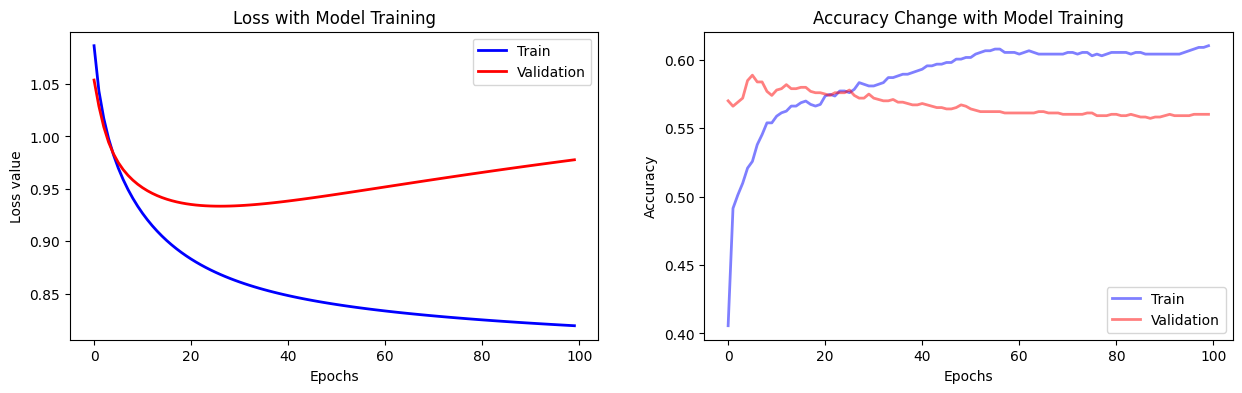

In [15]:
#Create LR model with x_train_under (undersampled) data
tf.random.set_seed(0)
tf.keras.utils.set_random_seed(0)
# 2. Build and compile model
# YOUR CODE HERE
model_lg = build_model_LG(
        num_features=x_train.shape[1],
        learning_rate=0.001
    )
# 3. Fit the model
# YOUR CODE HERE
fit_lg = model_lg.fit(
      x = x_train_under,
      y = y_train_under,
      epochs=100,
      batch_size=32,
      verbose=0,
      validation_data = (x_val, y_val['depression_severity'])
      )

# 4. Generate (1,2) plot
history = fit_lg.history
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(history['loss'], lw=2, color='blue')
ax1.plot(history['val_loss'], lw=2, color='red')
ax1.legend(['Train', 'Validation'], fontsize=10)
ax1.set_xlabel('Epochs', size=10)
ax1.set_ylabel("Loss value")
ax1.set_title('Loss with Model Training')

ax2.plot(history['accuracy'], lw=2, color='blue', alpha = 0.5)
ax2.plot(history['val_accuracy'], lw=2, color='red', alpha = 0.5)
ax2.legend(['Train', 'Validation'], fontsize=10)
ax2.set_xlabel('Epochs', size=10)
ax2.set_ylabel("Accuracy")
ax2.set_title('Accuracy Change with Model Training')

In [16]:
#Create predictions from x_train_under LR model to test recall
train_preds = model_lg.predict(x_train)
train_preds_labels = np.argmax(train_preds, axis=1)
train_accuracy = np.mean(y_train['depression_severity'] == train_preds_labels)
print(f'Train accuracy: {train_accuracy}')

test_preds = model_lg.predict(x_test)
test_preds_labels = np.argmax(test_preds, axis=1)
test_accuracy = np.mean(y_test['depression_severity'] == test_preds_labels)
print(f'Test accuracy: {test_accuracy}')

class_report = classification_report(y_test['depression_severity'], test_preds_labels, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "Logistic Regression"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_under"
df_report_final = pd.concat([df_report_final, df_report])

print(f'Classification report: \n {classification_report(y_test['depression_severity'], test_preds_labels)}')

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step
Train accuracy: 0.5950657894736842
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step
Test accuracy: 0.5818540433925049
Classification report: 
               precision    recall  f1-score   support

           0       0.89      0.64      0.74       776
           1       0.24      0.36      0.29       155
           2       0.16      0.43      0.24        83

    accuracy                           0.58      1014
   macro avg       0.43      0.48      0.42      1014
weighted avg       0.73      0.58      0.63      1014



In [17]:
#logistic regression model for binary classification

def build_model_LG_bin(num_features, learning_rate):
  """Build a TF linear regression model using Keras.

  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for SGD.

  Returns:
    model: A tf.keras model (graph).
  """
  # This is not strictly necessary, but each time you build a model, TF adds
  # new nodes (rather than overwriting), so the colab session can end up
  # storing lots of copies of the graph when you only care about the most
  # recent. Also, as there is some randomness built into training with SGD,
  # setting a random seed ensures that results are the same on each identical
  # training run.
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  # Build a model using keras.Sequential. While this is intended for neural
  # networks (which may have multiple layers), we want just a single layer for
  # binary logistic regression.
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Dense(
      units=1,        # output dim
      input_shape=(num_features,),  # input dim
      use_bias=True,               # use a bias (intercept) param
      activation='sigmoid',
      kernel_initializer=tf.ones_initializer,  # initialize params to 1
      bias_initializer=tf.ones_initializer,    # initialize bias to 1
  ))
  # model.add(tf.keras.layers.Softmax(axis=1))
  # We need to choose an optimizer. We'll use SGD, which is actually mini-batch GD
  optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

  # Finally, compile the model. Select the accuracy metric (!!!). This finalizes the graph for training.
  model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy'] 
    )
    
  return model

/home/jeff/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Text(0.5, 1.0, 'Accuracy Change with Model Training')

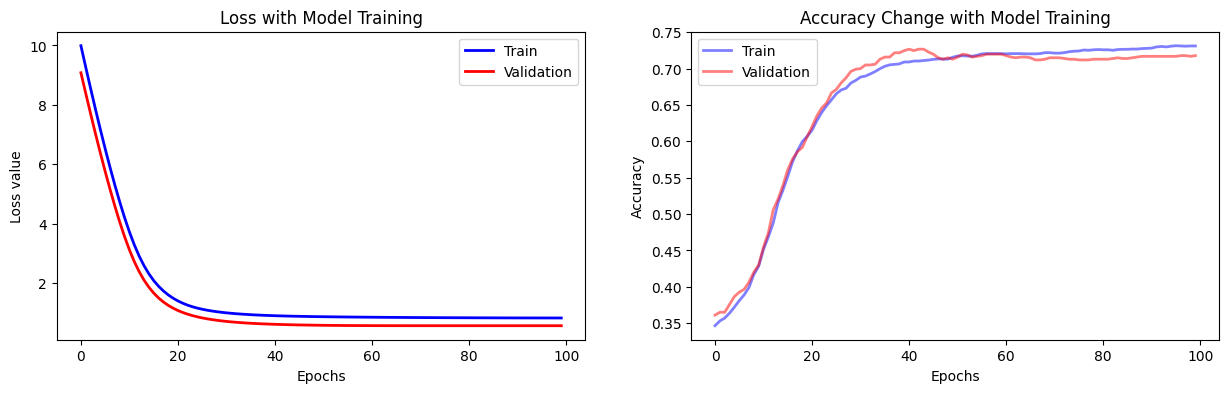

In [18]:
#Create LR model from x_train data for binary classification
tf.random.set_seed(0)
tf.keras.utils.set_random_seed(0)
class_weights = {0: 1., 1: 3}
# 2. Build and compile model
# YOUR CODE HERE
model_lg = build_model_LG_bin(
        num_features=x_train.shape[1],
        learning_rate=0.001
    )
# 3. Fit the model
# YOUR CODE HERE
fit_lg = model_lg.fit(
      x = x_train,
      y = y_train['depression_sign_binary'],
      epochs=100,
      batch_size=32,
      verbose=0,
      validation_data = (x_val, y_val['depression_sign_binary']),
      class_weight=class_weights
      )

# 4. Generate (1,2) plot
history = fit_lg.history
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(history['loss'], lw=2, color='blue')
ax1.plot(history['val_loss'], lw=2, color='red')
ax1.legend(['Train', 'Validation'], fontsize=10)
ax1.set_xlabel('Epochs', size=10)
ax1.set_ylabel("Loss value")
ax1.set_title('Loss with Model Training')

ax2.plot(history['accuracy'], lw=2, color='blue', alpha = 0.5)
ax2.plot(history['val_accuracy'], lw=2, color='red', alpha = 0.5)
ax2.legend(['Train', 'Validation'], fontsize=10)
ax2.set_xlabel('Epochs', size=10)
ax2.set_ylabel("Accuracy")
ax2.set_title('Accuracy Change with Model Training')

In [19]:
#Create predictions from x_train LR model with binary classification to test recall
train_preds = model_lg.predict(x_train)
train_preds_labels = np.round(train_preds)

test_preds = model_lg.predict(x_test)
test_preds_labels = np.round(test_preds)

class_report = classification_report(y_test['depression_sign_binary'], test_preds_labels, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "Logistic Regression"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])

print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], test_preds_labels)}')

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step
Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.70      0.77       776
           1       0.40      0.66      0.50       238

    accuracy                           0.69      1014
   macro avg       0.63      0.68      0.63      1014
weighted avg       0.76      0.69      0.71      1014



/home/jeff/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Text(0.5, 1.0, 'Accuracy Change with Model Training')

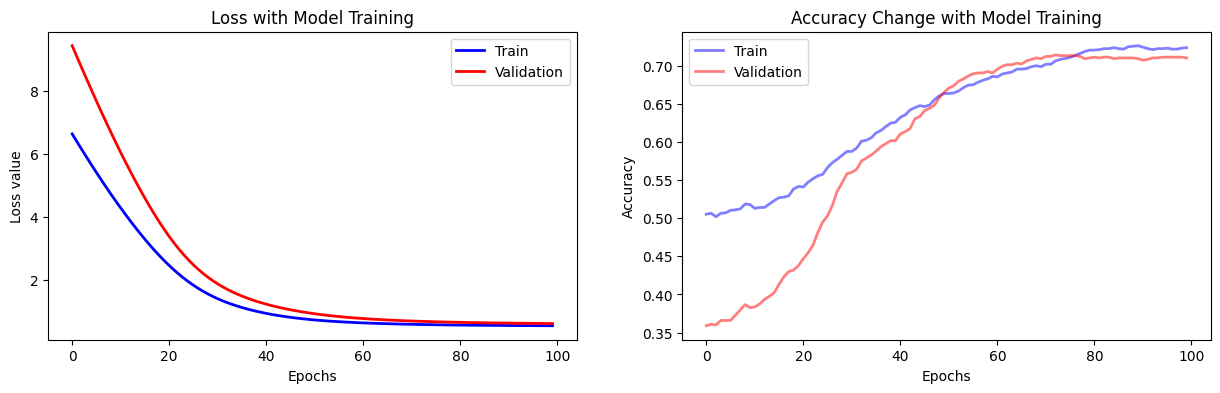

In [20]:
#Create LR model from x_train_under data for binary classification
tf.random.set_seed(0)
tf.keras.utils.set_random_seed(0)
class_weights = {0: 1., 1: 3}
# 2. Build and compile model
# YOUR CODE HERE
model_lg = build_model_LG_bin(
        num_features=x_train.shape[1],
        learning_rate=0.001
    )
# 3. Fit the model
# YOUR CODE HERE
fit_lg = model_lg.fit(
      x = x_train_under_bin,
      y = y_train_under_bin,
      epochs=100,
      batch_size=32,
      verbose=0,
      validation_data = (x_val, y_val['depression_sign_binary']),
      )

# 4. Generate (1,2) plot
history = fit_lg.history
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(history['loss'], lw=2, color='blue')
ax1.plot(history['val_loss'], lw=2, color='red')
ax1.legend(['Train', 'Validation'], fontsize=10)
ax1.set_xlabel('Epochs', size=10)
ax1.set_ylabel("Loss value")
ax1.set_title('Loss with Model Training')

ax2.plot(history['accuracy'], lw=2, color='blue', alpha = 0.5)
ax2.plot(history['val_accuracy'], lw=2, color='red', alpha = 0.5)
ax2.legend(['Train', 'Validation'], fontsize=10)
ax2.set_xlabel('Epochs', size=10)
ax2.set_ylabel("Accuracy")
ax2.set_title('Accuracy Change with Model Training')

In [21]:
#Create predictions from x_train_under LR model with binary classification to test recall
train_preds = model_lg.predict(x_train)
train_preds_labels = np.round(train_preds)

test_preds = model_lg.predict(x_test)
test_preds_labels = np.round(test_preds)

class_report = classification_report(y_test['depression_sign_binary'], test_preds_labels, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "Logistic Regression"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])

print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], test_preds_labels)}')

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 390us/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step
Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.70      0.78       776
           1       0.40      0.65      0.50       238

    accuracy                           0.69      1014
   macro avg       0.64      0.68      0.64      1014
weighted avg       0.76      0.69      0.71      1014



# RandomForest

Train Accuracy: 74.24%
Val Accuracy: 72.88%
Classification report: 
               precision    recall  f1-score   support

           0       0.77      1.00      0.87       776
           1       0.00      0.00      0.00       155
           2       0.00      0.00      0.00        83

    accuracy                           0.77      1014
   macro avg       0.26      0.33      0.29      1014
weighted avg       0.59      0.77      0.66      1014



/home/jeff/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jeff/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jeff/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/hom

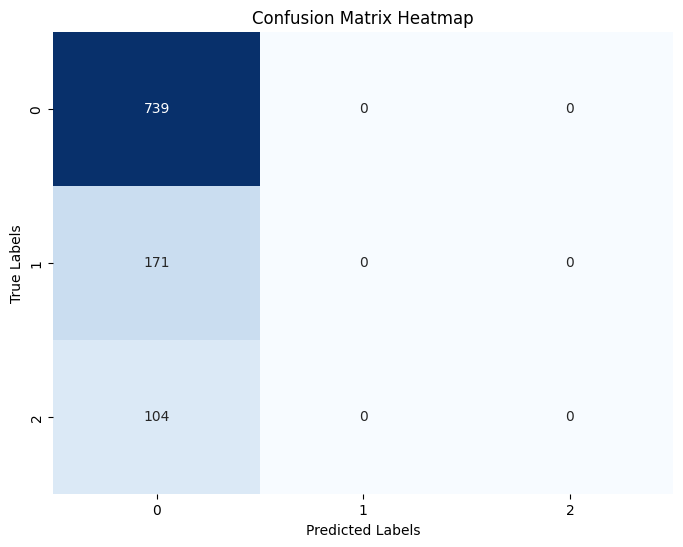

In [22]:
#Create RF classifier and train on x_train data for multiclass label
rf_clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=7, max_depth=12, max_features='log2', min_samples_leaf = 15, min_samples_split = 15)
rf_clf.fit(x_train, y_train['depression_severity'])
y_train_pred_rf = rf_clf.predict(x_train)
y_val_pred_rf = rf_clf.predict(x_val)
y_test_pred_rf = rf_clf.predict(x_test)
rf_clf_train_accuracy = accuracy_score(y_train['depression_severity'], y_train_pred_rf)
rf_clf_val_accuracy = accuracy_score(y_val['depression_severity'], y_val_pred_rf)

print(f'Train Accuracy: {rf_clf_train_accuracy * 100:.2f}%')
print(f'Val Accuracy: {rf_clf_val_accuracy * 100:.2f}%')

class_report = classification_report(y_test['depression_severity'], y_test_pred_rf, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "Random Forest"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])

print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_test_pred_rf)}')
conf_matrix = confusion_matrix(y_val['depression_severity'], y_val_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Train Accuracy: 93.12%
Val Accuracy: 67.36%
Classification report: 
               precision    recall  f1-score   support

           0       0.85      0.81      0.83       776
           1       0.26      0.30      0.28       155
           2       0.20      0.24      0.22        83

    accuracy                           0.68      1014
   macro avg       0.44      0.45      0.44      1014
weighted avg       0.71      0.68      0.69      1014



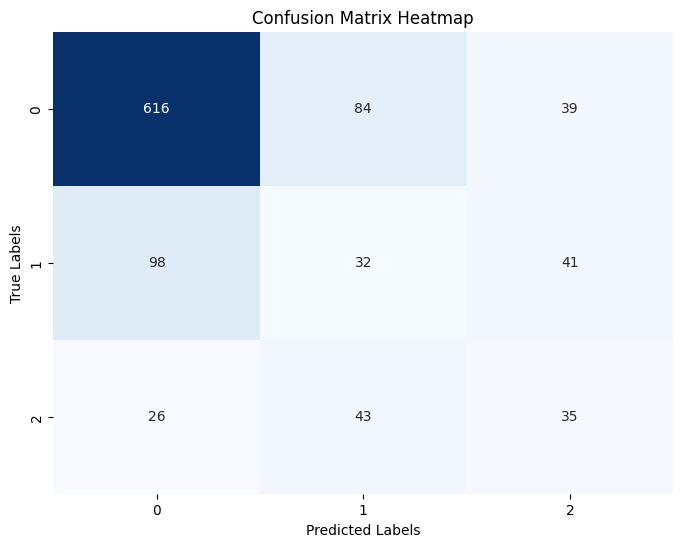

In [23]:
#Create RF classifier and train on x_train_bal (upsampled) data for multiclass label
rf_clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=7, max_depth=12, max_features='log2', min_samples_leaf = 15, min_samples_split = 15)
rf_clf.fit(x_train_bal, y_train_bal['depression_severity'])
y_train_pred_rf = rf_clf.predict(x_train_bal)
y_val_pred_rf = rf_clf.predict(x_val)
y_test_pred_rf = rf_clf.predict(x_test)
rf_clf_train_accuracy = accuracy_score(y_train_bal['depression_severity'], y_train_pred_rf)
rf_clf_val_accuracy = accuracy_score(y_val['depression_severity'], y_val_pred_rf)
print(f'Train Accuracy: {rf_clf_train_accuracy * 100:.2f}%')
print(f'Val Accuracy: {rf_clf_val_accuracy * 100:.2f}%')

class_report = classification_report(y_test['depression_severity'], y_test_pred_rf, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "Random Forest"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_bal"
df_report_final = pd.concat([df_report_final, df_report])

print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_test_pred_rf)}')
conf_matrix = confusion_matrix(y_val['depression_severity'], y_val_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Train Accuracy: 75.25%
Val Accuracy: 59.96%
Classification report: 
               precision    recall  f1-score   support

           0       0.77      0.61      0.68       776
           1       0.14      0.12      0.13       155
           2       0.11      0.35      0.16        83

    accuracy                           0.51      1014
   macro avg       0.34      0.36      0.32      1014
weighted avg       0.62      0.51      0.55      1014



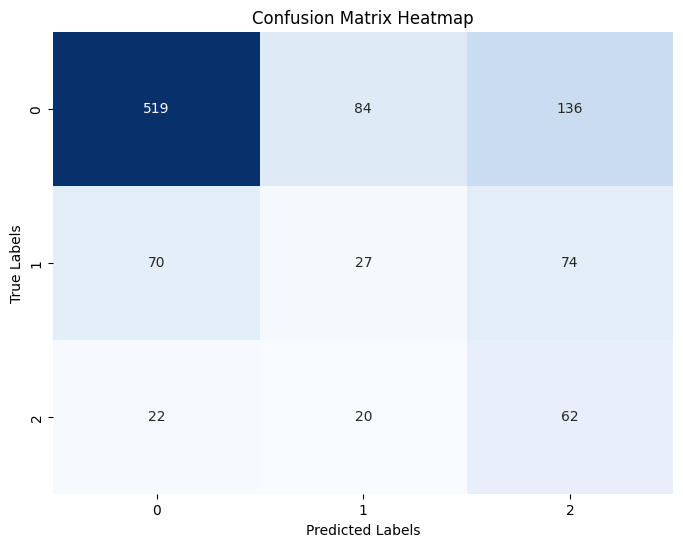

In [24]:
#Create RF classifier and train on x_train_under (undersampled) data for multiclass label
rf_clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=7, max_depth=12, max_features='log2', min_samples_leaf = 15, min_samples_split = 15)
rf_clf.fit(x_train_under, y_train_under)
y_train_pred_rf = rf_clf.predict(x_train_under)
y_val_pred_rf = rf_clf.predict(x_val)
rf_clf_train_accuracy = accuracy_score(y_train_under, y_train_pred_rf)
rf_clf_val_accuracy = accuracy_score(y_val['depression_severity'], y_val_pred_rf)
print(f'Train Accuracy: {rf_clf_train_accuracy * 100:.2f}%')
print(f'Val Accuracy: {rf_clf_val_accuracy * 100:.2f}%')
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_val_pred_rf)}')

class_report = classification_report(y_test['depression_severity'], y_val_pred_rf, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "Random Forest"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_under"
df_report_final = pd.concat([df_report_final, df_report])

conf_matrix = confusion_matrix(y_val['depression_severity'], y_val_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Train Accuracy: 79.14%
Val Accuracy: 75.25%
Classification report: 
               precision    recall  f1-score   support

           0       0.78      1.00      0.87       776
           1       0.93      0.06      0.11       238

    accuracy                           0.78      1014
   macro avg       0.85      0.53      0.49      1014
weighted avg       0.81      0.78      0.69      1014



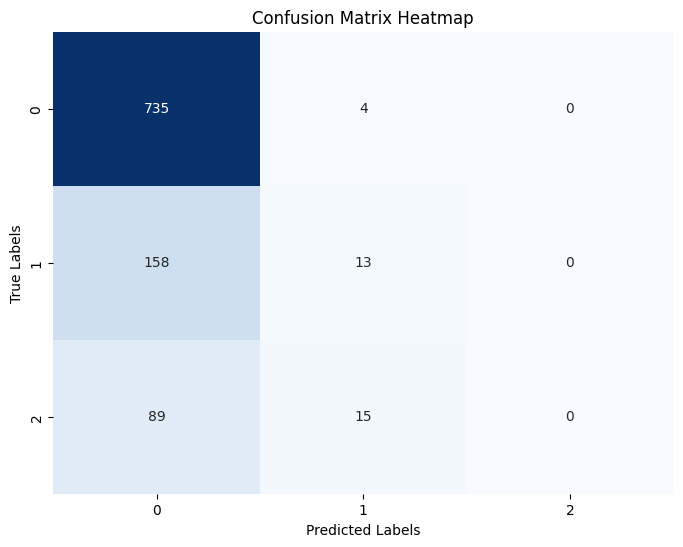

In [25]:
#Create RF classifier and train on x_train data for binary label
rf_clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=7, max_depth=12, max_features='log2', min_samples_leaf = 15, min_samples_split = 15)
rf_clf.fit(x_train, y_train['depression_sign_binary'])
y_train_pred_rf = rf_clf.predict(x_train)
y_val_pred_rf = rf_clf.predict(x_val)
y_test_pred_rf = rf_clf.predict(x_test)
rf_clf_train_accuracy = accuracy_score(y_train['depression_sign_binary'], y_train_pred_rf)
rf_clf_val_accuracy = accuracy_score(y_val['depression_sign_binary'], y_val_pred_rf)
print(f'Train Accuracy: {rf_clf_train_accuracy * 100:.2f}%')
print(f'Val Accuracy: {rf_clf_val_accuracy * 100:.2f}%')
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_test_pred_rf)}')

class_report = classification_report(y_test['depression_sign_binary'], y_test_pred_rf, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "Random Forest"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])

conf_matrix = confusion_matrix(y_val['depression_severity'], y_val_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Train Accuracy: 80.59%
Val Accuracy: 71.01%
Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.71      0.78       776
           1       0.41      0.66      0.50       238

    accuracy                           0.70      1014
   macro avg       0.64      0.68      0.64      1014
weighted avg       0.76      0.70      0.72      1014



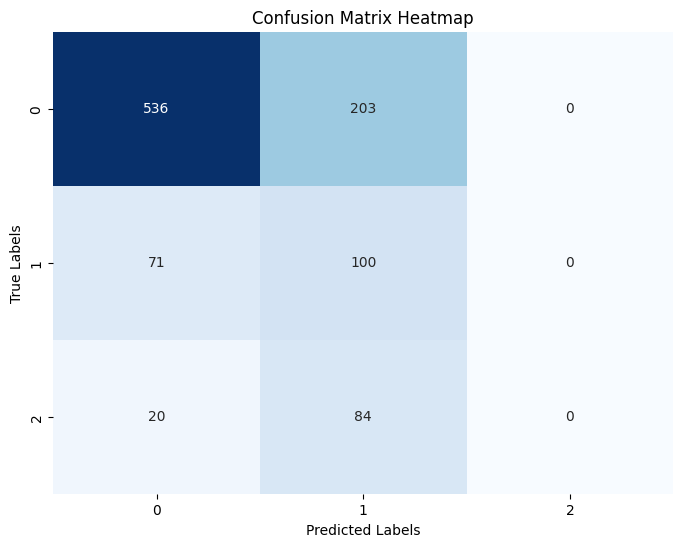

In [26]:
#Create RF classifier and train on x_train_under (undersampled) data for binary label
rf_clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=7, max_depth=12, max_features='log2', min_samples_leaf = 15, min_samples_split = 15)
rf_clf.fit(x_train_under_bin, y_train_under_bin)
y_train_pred_rf = rf_clf.predict(x_train_under_bin)
y_val_pred_rf = rf_clf.predict(x_val)
y_test_pred_rf = rf_clf.predict(x_test)
rf_clf_train_accuracy = accuracy_score(y_train_under_bin, y_train_pred_rf)
rf_clf_val_accuracy = accuracy_score(y_val['depression_sign_binary'], y_val_pred_rf)
print(f'Train Accuracy: {rf_clf_train_accuracy * 100:.2f}%')
print(f'Val Accuracy: {rf_clf_val_accuracy * 100:.2f}%')
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_test_pred_rf)}')

class_report = classification_report(y_test['depression_sign_binary'], y_test_pred_rf, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "Random Forest"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train_under"
df_report_final = pd.concat([df_report_final, df_report])

conf_matrix = confusion_matrix(y_val['depression_severity'], y_val_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Naive Bayes

In [27]:
#Create GuassianNB with x_train data for multiclass label
model = GaussianNB()
model.fit(x_train, y_train['depression_severity'])
y_pred = model.predict(x_test)
accuray = accuracy_score(y_pred, y_test['depression_severity'])
f1 = f1_score(y_pred, y_test['depression_severity'], average="weighted")

print("Accuracy:", accuray)
print("F1 Score:", f1)

Accuracy: 0.09467455621301775
F1 Score: 0.14990671677083492


In [28]:
#Create GuassianNB with x_train_bal (upscaled) data for multiclass label
model = GaussianNB()
model.fit(x_train_bal, y_train_bal['depression_severity'])
y_pred = model.predict(x_test)
accuray = accuracy_score(y_pred, y_test['depression_severity'])
f1 = f1_score(y_pred, y_test['depression_severity'], average="weighted")

print("Accuracy:", accuray)
print("F1 Score:", f1)

Accuracy: 0.08579881656804733
F1 Score: 0.13838757843205582


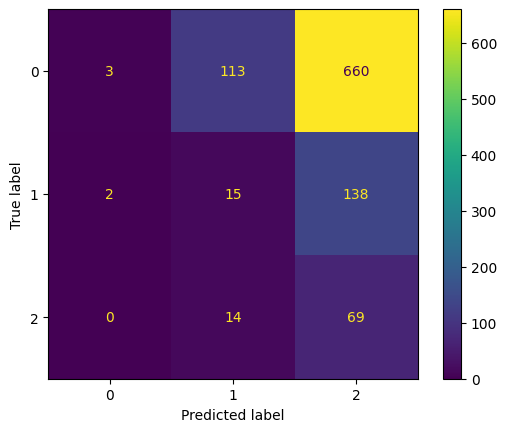

In [29]:
cm = confusion_matrix(y_test['depression_severity'], y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();

In [30]:
#Create scaler for minmax scaling to allow for complementNB (this needs to be reworked with unscaled data eventually)
scaler = MinMaxScaler()
x_train_minmax = scaler.fit_transform(x_train)
x_val_minmax = scaler.transform(x_val)
x_test_minmax = scaler.transform(x_test)
x_train_bal_minmax = scaler.fit_transform(x_train_bal)

In [31]:
#Run ComplementNB model with x_train data (twice scaled) for multiclass label
model = ComplementNB()
model.fit(x_train_minmax, y_train['depression_severity'])
y_pred = model.predict(x_test_minmax)
accuracy = accuracy_score(y_pred, y_test['depression_severity'])
f1 = f1_score(y_pred, y_test['depression_severity'], average="weighted")

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "ComplementNB"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_minmax(twice scaled)"
df_report_final = pd.concat([df_report_final, df_report])


Accuracy: 0.6439842209072978
F1 Score: 0.6134805233334474
Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.74      0.80       776
           1       0.28      0.38      0.32       155
           2       0.16      0.28      0.20        83

    accuracy                           0.64      1014
   macro avg       0.44      0.46      0.44      1014
weighted avg       0.72      0.64      0.67      1014



In [32]:
#Run ComplementNB model with x_train data (twice scaled) for binary label
model = ComplementNB()
model.fit(x_train_minmax, y_train['depression_sign_binary'])
y_pred = model.predict(x_test_minmax)
accuracy = accuracy_score(y_pred, y_test['depression_sign_binary'])
f1 = f1_score(y_pred, y_test['depression_sign_binary'], average="weighted")

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

class_report = classification_report(y_test['depression_sign_binary'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "ComplementNB"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train_minmax(twice scaled)"
df_report_final = pd.concat([df_report_final, df_report])

Accuracy: 0.7041420118343196
F1 Score: 0.6854767715263153
Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.72      0.79       776
           1       0.42      0.66      0.51       238

    accuracy                           0.70      1014
   macro avg       0.64      0.69      0.65      1014
weighted avg       0.77      0.70      0.72      1014



In [33]:
#Run ComplementNB model with x_train_bal (upscaled) data (twice scaled) for multiclass label
model = ComplementNB()
model.fit(x_train_bal_minmax, y_train_bal['depression_severity'])
y_pred = model.predict(x_test_minmax)
accuracy = accuracy_score(y_pred, y_test['depression_severity'])
f1 = f1_score(y_pred, y_test['depression_severity'], average="weighted")

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "ComplementNB"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_bal_minmax(twice scaled)"
df_report_final = pd.concat([df_report_final, df_report])

Accuracy: 0.6331360946745562
F1 Score: 0.615572338321949
Classification report: 
               precision    recall  f1-score   support

           0       0.86      0.76      0.81       776
           1       0.14      0.06      0.09       155
           2       0.16      0.51      0.25        83

    accuracy                           0.63      1014
   macro avg       0.39      0.44      0.38      1014
weighted avg       0.69      0.63      0.65      1014



In [34]:
#Run ComplementNB model with x_train_bal (upscaled) data (twice scaled) for binary label
model = ComplementNB()
model.fit(x_train_bal_minmax, y_train_bal['depression_sign_binary'])
y_pred = model.predict(x_test_minmax)
accuracy = accuracy_score(y_pred, y_test['depression_sign_binary'])
f1 = f1_score(y_pred, y_test['depression_sign_binary'], average="weighted")

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

class_report = classification_report(y_test['depression_sign_binary'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "ComplementNB"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train_bal_minmax(twice scaled)"
df_report_final = pd.concat([df_report_final, df_report])

Accuracy: 0.7159763313609467
F1 Score: 0.6997949965888559
Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.74      0.80       776
           1       0.43      0.63      0.51       238

    accuracy                           0.72      1014
   macro avg       0.65      0.69      0.66      1014
weighted avg       0.77      0.72      0.73      1014



In [35]:
#Create scaler for actual unscaled data (generated outside of this file)
scaler2 = MinMaxScaler()
x_train_minmax2 = scaler2.fit_transform(x_train_unscaled)
x_val_minmax2 = scaler2.transform(x_val_unscaled)
x_test_minmax2 = scaler2.transform(x_test_unscaled)


In [36]:
#Create complementNB model with x_train_minmax (scaled once) data for multiclass label
model = ComplementNB()
model.fit(x_train_minmax2, y_train['depression_severity'])
y_pred = model.predict(x_test_minmax2)
accuracy = accuracy_score(y_pred, y_test['depression_severity'])
f1 = f1_score(y_pred, y_test['depression_severity'], average="weighted")

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

Accuracy: 0.6390532544378699
F1 Score: 0.6135607689014283
Classification report: 
               precision    recall  f1-score   support

           0       0.84      0.75      0.80       776
           1       0.27      0.27      0.27       155
           2       0.13      0.25      0.17        83

    accuracy                           0.64      1014
   macro avg       0.41      0.43      0.41      1014
weighted avg       0.70      0.64      0.66      1014



In [37]:
#Create complementNB model with x_train_minmax (scaled once) data for binary label
model = ComplementNB()
model.fit(x_train_minmax2, y_train['depression_sign_binary'])
y_pred = model.predict(x_test_minmax2)
accuracy = accuracy_score(y_pred, y_test['depression_sign_binary'])
f1 = f1_score(y_pred, y_test['depression_sign_binary'], average="weighted")

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

Accuracy: 0.6972386587771203
F1 Score: 0.6821456500999816
Classification report: 
               precision    recall  f1-score   support

           0       0.84      0.74      0.79       776
           1       0.40      0.55      0.46       238

    accuracy                           0.70      1014
   macro avg       0.62      0.65      0.63      1014
weighted avg       0.74      0.70      0.71      1014



# Support Vector Machine

In [38]:
#Create svm model from x_train data for multiclass label
svm_clf = svm.SVC(decision_function_shape='ovo')
svm_clf.fit(x_train,y_train['depression_severity'])
y_pred = svm_clf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test['depression_severity'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "SVM"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])


Accuracy: 0.7652859960552268
Classification report: 
               precision    recall  f1-score   support

           0       0.77      1.00      0.87       776
           1       0.00      0.00      0.00       155
           2       0.00      0.00      0.00        83

    accuracy                           0.77      1014
   macro avg       0.26      0.33      0.29      1014
weighted avg       0.59      0.77      0.66      1014



/home/jeff/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jeff/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jeff/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/hom

In [39]:
#Create svm model from x_train weighted data for multiclass label
class_weights = {0: 1., 1: 5., 2:7.}
svm_clf = svm.SVC(decision_function_shape='ovo', class_weight=class_weights)
svm_clf.fit(x_train,y_train['depression_severity'])
y_pred = svm_clf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test['depression_severity'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "SVM"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train weighted"
df_report_final = pd.concat([df_report_final, df_report])

Accuracy: 0.6282051282051282
Classification report: 
               precision    recall  f1-score   support

           0       0.83      0.75      0.79       776
           1       0.18      0.25      0.21       155
           2       0.19      0.22      0.20        83

    accuracy                           0.63      1014
   macro avg       0.40      0.40      0.40      1014
weighted avg       0.67      0.63      0.65      1014



In [40]:
#Create svm model from x_train_bal (upscaled) data for multiclass label
svm_clf = svm.SVC(decision_function_shape='ovo')
svm_clf.fit(x_train_bal,y_train_bal['depression_severity'])
y_pred = svm_clf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test['depression_severity'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "SVM"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_bal"
df_report_final = pd.concat([df_report_final, df_report])


Accuracy: 0.645956607495069
Classification report: 
               precision    recall  f1-score   support

           0       0.82      0.78      0.80       776
           1       0.19      0.21      0.20       155
           2       0.18      0.23      0.20        83

    accuracy                           0.65      1014
   macro avg       0.40      0.41      0.40      1014
weighted avg       0.67      0.65      0.66      1014



In [41]:
#Create svm model from x_train_under (underscaled) data for multiclass label
svm_clf = svm.SVC(decision_function_shape='ovo')
svm_clf.fit(x_train_under,y_train_under)
y_pred = svm_clf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test['depression_severity'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "SVM"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_under"
df_report_final = pd.concat([df_report_final, df_report])

Accuracy: 0.5305719921104537
Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.60      0.71       776
           1       0.17      0.26      0.21       155
           2       0.14      0.41      0.20        83

    accuracy                           0.53      1014
   macro avg       0.39      0.42      0.37      1014
weighted avg       0.70      0.53      0.59      1014



In [42]:
#Create svm model from x_train_bal (upscaled) data for binary label
svm_clf = svm.SVC(decision_function_shape='ovo')
svm_clf.fit(x_train_bal,y_train_bal['depression_sign_binary'])
y_pred = svm_clf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test['depression_sign_binary'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

class_report = classification_report(y_test['depression_sign_binary'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "SVM"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train_bal"
df_report_final = pd.concat([df_report_final, df_report])

Accuracy: 0.665680473372781
Classification report: 
               precision    recall  f1-score   support

           0       0.85      0.68      0.76       776
           1       0.37      0.61      0.46       238

    accuracy                           0.67      1014
   macro avg       0.61      0.65      0.61      1014
weighted avg       0.74      0.67      0.69      1014



In [43]:
#Create svm model from x_train_under (underscaled) data for binary label
svm_clf = svm.SVC(decision_function_shape='ovo')
svm_clf.fit(x_train_under_bin,y_train_under_bin)
y_pred = svm_clf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test['depression_sign_binary'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

class_report = classification_report(y_test['depression_sign_binary'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "SVM"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train_under"
df_report_final = pd.concat([df_report_final, df_report])

Accuracy: 0.6775147928994083
Classification report: 
               precision    recall  f1-score   support

           0       0.86      0.69      0.77       776
           1       0.39      0.64      0.48       238

    accuracy                           0.68      1014
   macro avg       0.62      0.66      0.62      1014
weighted avg       0.75      0.68      0.70      1014



# XGBoost

In [44]:
#Create XGBoost Model from x_train data for multiclass label
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    num_boost_round=100,
    learning_rate=0.01,     
    max_depth=10,            
    n_estimators=100,      
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=0,              
    booster='dart',    
    tree_method='auto',    
    scale_pos_weight=5,
    eval_metric = 'auc'  
)
model.fit(x_train, y_train['depression_severity'])
y_pred = model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_severity'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "XGB"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])


/home/jeff/miniconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:25:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_boost_round", "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM Accuracy: 0.7652859960552268
Classification report: 
               precision    recall  f1-score   support

           0       0.77      1.00      0.87       776
           1       0.00      0.00      0.00       155
           2       0.00      0.00      0.00        83

    accuracy                           0.77      1014
   macro avg       0.26      0.33      0.29      1014
weighted avg       0.59      0.77      0.66      1014



/home/jeff/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jeff/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jeff/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/hom

In [45]:
#Create XGBoost Model from x_train_bal (upscaled) data for multiclass label
model.fit(x_train_bal, y_train_bal['depression_severity'])
y_pred = model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_severity'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "XGB"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_bal"
df_report_final = pd.concat([df_report_final, df_report])

/home/jeff/miniconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:25:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_boost_round", "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM Accuracy: 0.7258382642998028
Classification report: 
               precision    recall  f1-score   support

           0       0.83      0.89      0.86       776
           1       0.28      0.15      0.19       155
           2       0.21      0.25      0.23        83

    accuracy                           0.73      1014
   macro avg       0.44      0.43      0.43      1014
weighted avg       0.70      0.73      0.71      1014



In [46]:
#Create XGBoost Model from x_train_under data for multiclass label
model.fit(x_train_under, y_train_under)
y_pred = model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_severity'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "XGB"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_under"
df_report_final = pd.concat([df_report_final, df_report])

/home/jeff/miniconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:25:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_boost_round", "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM Accuracy: 0.5670611439842209
Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.64      0.74       776
           1       0.21      0.25      0.23       155
           2       0.16      0.51      0.24        83

    accuracy                           0.57      1014
   macro avg       0.41      0.46      0.40      1014
weighted avg       0.71      0.57      0.62      1014



In [47]:
#Create XGBoost Model from x_train weighted data for multiclass label
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train['depression_severity'] #provide your own target name
)
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    num_boost_round=100,
    learning_rate=0.01,     
    max_depth=20,            
    n_estimators=300,      
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=0,              
    booster='dart',    
    tree_method='auto',
    eval_metric = 'auc' 
)
model.fit(x_train, y_train['depression_severity'], sample_weight = sample_weights)
y_pred = model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_severity'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "XGB"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train weighted"
df_report_final = pd.concat([df_report_final, df_report])

/home/jeff/miniconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:25:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM Accuracy: 0.7485207100591716
Classification report: 
               precision    recall  f1-score   support

           0       0.80      0.95      0.87       776
           1       0.27      0.08      0.12       155
           2       0.17      0.10      0.12        83

    accuracy                           0.75      1014
   macro avg       0.41      0.38      0.37      1014
weighted avg       0.67      0.75      0.69      1014



In [48]:
#Create XGBoost Model from x_train data for binary label

model = xgb.XGBClassifier(
    objective='binary:logistic',
    num_boost_round=100,
    learning_rate=0.01,     
    max_depth=20,            
    n_estimators=300,      
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=0,              
    booster='dart',    
    tree_method='auto',
    eval_metric = 'auc' 
)
model.fit(x_train, y_train['depression_sign_binary'])
y_pred = model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_sign_binary'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

class_report = classification_report(y_test['depression_sign_binary'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "XGB"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])

/home/jeff/miniconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:26:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM Accuracy: 0.7840236686390533
Classification report: 
               precision    recall  f1-score   support

           0       0.80      0.95      0.87       776
           1       0.60      0.24      0.34       238

    accuracy                           0.78      1014
   macro avg       0.70      0.59      0.60      1014
weighted avg       0.76      0.78      0.75      1014



In [49]:
#Create XGBoost Model from x_train_bal (upscaled) data for binary label
model.fit(x_train_bal, y_train_bal['depression_sign_binary'])
y_pred = model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_sign_binary'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

class_report = classification_report(y_test['depression_sign_binary'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "XGB"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])

/home/jeff/miniconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:26:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM Accuracy: 0.7544378698224852
Classification report: 
               precision    recall  f1-score   support

           0       0.85      0.82      0.84       776
           1       0.48      0.53      0.50       238

    accuracy                           0.75      1014
   macro avg       0.67      0.68      0.67      1014
weighted avg       0.76      0.75      0.76      1014



In [50]:
#Create XGBoost Model from x_train_under (underscaled) data for binary label
model.fit(x_train_under_bin, y_train_under_bin)
y_pred = model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_sign_binary'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

class_report = classification_report(y_test['depression_sign_binary'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "XGB"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])

/home/jeff/miniconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:27:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM Accuracy: 0.7001972386587771
Classification report: 
               precision    recall  f1-score   support

           0       0.88      0.70      0.78       776
           1       0.42      0.69      0.52       238

    accuracy                           0.70      1014
   macro avg       0.65      0.70      0.65      1014
weighted avg       0.77      0.70      0.72      1014



# Light Gradient Boosted Machine (Light-GBM)

In [51]:
#Create LGBM model with x_train weighted data for multiclass label
lgbm_model = lgb.LGBMClassifier(
    max_depth = -1,
    learning_rate = 0.1,
    n_estimators = 100,
    objective = 'multiclass',
    class_weight = 'balanced'
)
lgbm_model.fit(x_train,y_train['depression_severity'])
y_pred = lgbm_model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_severity'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "LGBM"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train weighted"
df_report_final = pd.concat([df_report_final, df_report])

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000786 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6833
[LightGBM] [Info] Number of data points in the train set: 3040, number of used features: 116
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
SVM Accuracy: 0.7347140039447732
Classification report: 
               precision    recall  f1-score   support

           0       0.82      0.90      0.86       776
           1       0.31      0.25      0.27       155
           2       0.23      0.12      0.16        83

    accuracy                           0.73      1014
   macro avg       0.45      0.42      0.43      1014
weighted avg       0.70      0.73      0.71      1014



In [52]:
#Create LGBM model with x_train_bal (uscaled) data for multiclass label
lgbm_model = lgb.LGBMClassifier(
    max_depth = -1,
    learning_rate = 0.1,
    n_estimators = 100,
    objective = 'multiclass',
    # class_weight = 'balanced'
)
lgbm_model.fit(x_train_bal,y_train_bal['depression_severity'])
y_pred = lgbm_model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_severity'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "LGBM"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_bal"
df_report_final = pd.concat([df_report_final, df_report])

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7057
[LightGBM] [Info] Number of data points in the train set: 6771, number of used features: 133
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
SVM Accuracy: 0.7386587771203156
Classification report: 
               precision    recall  f1-score   support

           0       0.81      0.91      0.86       776
           1       0.29      0.18      0.22       155
           2       0.26      0.13      0.18        83

    accuracy                           0.74      1014
   macro avg       0.45      0.41      0.42      1014
weighted avg       0.69      0.74      0.71      1014



In [53]:
#Create LGBM model with x_train data for multiclass label
lgbm_model = lgb.LGBMClassifier(
    max_depth = -1,
    learning_rate = 0.1,
    n_estimators = 100,
    objective = 'multiclass',
    # class_weight = 'balanced'
)
lgbm_model.fit(x_train,y_train['depression_severity'])
y_pred = lgbm_model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_severity'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "LGBM"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000748 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6833
[LightGBM] [Info] Number of data points in the train set: 3040, number of used features: 116
[LightGBM] [Info] Start training from score -0.297821
[LightGBM] [Info] Start training from score -1.783243
[LightGBM] [Info] Start training from score -2.413811
SVM Accuracy: 0.7662721893491125
Classification report: 
               precision    recall  f1-score   support

           0       0.79      0.97      0.87       776
           1       0.37      0.12      0.18       155
           2       0.27      0.04      0.06        83

    accuracy                           0.77      1014
   macro avg       0.48      0.38      0.37      1014
weighted avg       0.68      0.77      0.70      1014



In [54]:
#Create LGBM model with x_train_under (undersampled) data for multiclass label
lgbm_model = lgb.LGBMClassifier(
    max_depth = -1,
    learning_rate = 0.1,
    n_estimators = 100,
    objective = 'multiclass',
    # class_weight = 'balanced'
)
lgbm_model.fit(x_train_under,y_train_under)
y_pred = lgbm_model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_severity'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "LGBM"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_under"
df_report_final = pd.concat([df_report_final, df_report])

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000368 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5632
[LightGBM] [Info] Number of data points in the train set: 816, number of used features: 100
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

In [55]:
#Create LGBM model with x_train data for binary label
lgbm_model = lgb.LGBMClassifier(
    max_depth = -1,
    learning_rate = 0.1,
    n_estimators = 100,
    objective = 'binary',
    # class_weight = 'balanced'
)
lgbm_model.fit(x_train,y_train['depression_sign_binary'])
y_pred = lgbm_model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_sign_binary'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

class_report = classification_report(y_test['depression_sign_binary'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "LGBM"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 783, number of negative: 2257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000675 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6833
[LightGBM] [Info] Number of data points in the train set: 3040, number of used features: 116
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.257566 -> initscore=-1.058659
[LightGBM] [Info] Start training from score -1.058659
SVM Accuracy: 0.7928994082840237
Classification report: 
               precision    recall  f1-score   support

           0       0.82      0.93      0.87       776
           1       0.60      0.34      0.44       238

    accuracy                           0.79      1014
   macro avg       0.71      0.64      0.65      1014
weighted avg       0.77      0.79      0.77      1014



In [56]:
#Create LGBM model with x_train_under (undersampled) data for binary label
lgbm_model = lgb.LGBMClassifier(
    max_depth = -1,
    learning_rate = 0.1,
    n_estimators = 100,
    objective = 'binary',
    # class_weight = 'balanced'
)
lgbm_model.fit(x_train_under_bin,y_train_under_bin)
y_pred = lgbm_model.predict(x_test)
print("SVM Accuracy:", accuracy_score(y_test['depression_sign_binary'], y_pred))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

class_report = classification_report(y_test['depression_sign_binary'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "LGBM"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train_under"
df_report_final = pd.concat([df_report_final, df_report])

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 783, number of negative: 783
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000548 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6373
[LightGBM] [Info] Number of data points in the train set: 1566, number of used features: 106
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
SVM Accuracy: 0.6755424063116371
Classification report: 
               precision    recall  f1-score   support

           0       0.88      0.67      0.76       776
           1       0.39      0.69      0.50       238

    accuracy                           0.68      1014
   macro avg       0.63      0.68      0.63      1014
weighted avg       0.76      0.68      0.70      1014



# Feed Forward Neural Network (FNN)

In [57]:
#Create neural network model to be used for multiclass label with options to customize optimizer, activation, hidden layers, learning rate and metric
def build_model(n_classes,
                hidden_layer_sizes=[],
                activation='relu',
                optimizer='Adam',
                learning_rate=0.01,
                metric='metric'):
    """Build a multi-class logistic regression model using Keras.

    Args:
    n_classes: Number of output classes in the dataset.
    hidden_layer_sizes: A list with the number of units in each hidden layer.
    activation: The activation function to use for the hidden layers.
    optimizer: The optimizer to use (SGD, Adam).
    learning_rate: The desired learning rate for the optimizer.
    metric: The desired metric.

    Returns:
    model: A tf.keras model (graph).
    """
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    #This keras random seed is necessary for reproducibility- should have been added to function
    keras.utils.set_random_seed(0)

    # YOUR CODE HERE
    optimizer_dic = {"SGD": tf.keras.optimizers.SGD(learning_rate=learning_rate),
                     "Adam": tf.keras.optimizers.Adam(learning_rate=learning_rate)
                     }
    model = tf.keras.Sequential()
    j = 1
    model.add(tf.keras.Input(shape=(146,), name='Input'))
    for hidden_layer_size in hidden_layer_sizes:
        model.add(tf.keras.layers.Dense(units=hidden_layer_size,
                                        activation=activation,
                                        name=f'Hidden_{j}'))
        model.add(tf.keras.layers.Dropout(0.4, name=f'Dropout_{j}')) 
        j+=1
    model.add(tf.keras.layers.Dense(units=n_classes, activation='softmax', name='Output'))
    model.compile(
        optimizer=optimizer_dic[optimizer],
        loss='sparse_categorical_crossentropy',
        metrics=[metric] 
    )


    return model

Training the x_train multi model...


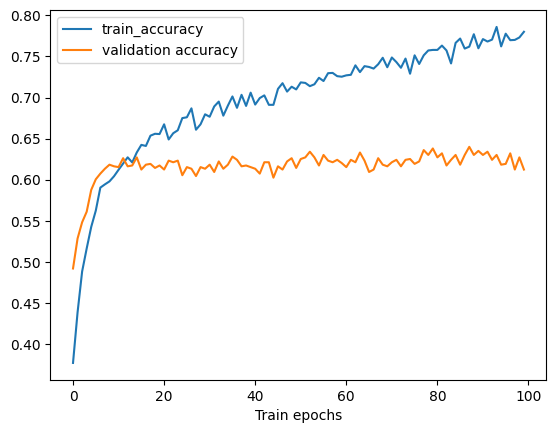

Training accuracy: 0.7799
Validation accuracy: 0.6124
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Classification report: 
               precision    recall  f1-score   support

           0       0.85      0.74      0.79       776
           1       0.22      0.32      0.26       155
           2       0.21      0.30      0.25        83

    accuracy                           0.64      1014
   macro avg       0.43      0.45      0.43      1014
weighted avg       0.71      0.64      0.67      1014



In [58]:
#Train FNN model with x_train data for multi class label
def train_and_evaluate(data='x_train multi',
                       hidden_layer_sizes=[50],
                       activation='relu',
                       optimizer='Adam',
                       learning_rate=0.001,
                       metric=tf.keras.metrics.SparseCategoricalAccuracy(),
                       num_epochs=100):

  # Build the model.
    model = build_model(n_classes=3,
                      hidden_layer_sizes=hidden_layer_sizes,
                      activation=activation,
                      optimizer=optimizer,
                      metric=metric,
                      learning_rate=learning_rate)


    X_train = x_train
    X_val = x_val
    Y_train = y_train['depression_severity']
    Y_val = y_val['depression_severity']
    
  # Train the model.
    print('Training the', data, 'model...')
    history = model.fit(
        x=X_train,
        y=Y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_data=(X_val,Y_val),
        verbose=0,
        class_weight=class_weights
        )

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_accuracy = history.history['sparse_categorical_accuracy']
    val_accuracy = history.history['val_sparse_categorical_accuracy']
    plt.plot(train_accuracy, label='train_accuracy')
    plt.plot(val_accuracy, label='validation accuracy')
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()
    
    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    
    return model


# run the function
model = train_and_evaluate()
y_pred = np.argmax(model.predict(x_test), axis=1)
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "FNN"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])

Training the x_train_bal multi model...


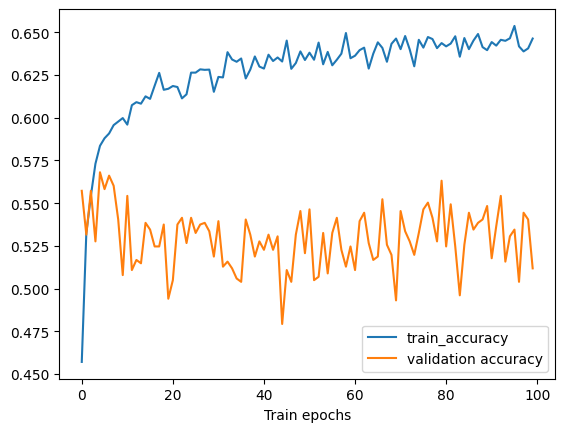

Training accuracy: 0.6463
Validation accuracy: 0.5118
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step
Classification report: 
               precision    recall  f1-score   support

           0       0.88      0.61      0.72       776
           1       0.16      0.25      0.20       155
           2       0.16      0.46      0.23        83

    accuracy                           0.54      1014
   macro avg       0.40      0.44      0.38      1014
weighted avg       0.71      0.54      0.60      1014



In [59]:
#Train FNN model with x_train_bal (upscaled) data for multi class label
def train_and_evaluate(data='x_train_bal multi',
                       hidden_layer_sizes=[10],
                       activation='relu',
                       optimizer='Adam',
                       learning_rate=0.01,
                       metric=tf.keras.metrics.SparseCategoricalAccuracy(),
                       num_epochs=100):

  # Build the model.
    model = build_model(n_classes=3,
                      hidden_layer_sizes=hidden_layer_sizes,
                      activation=activation,
                      optimizer=optimizer,
                      metric=metric,
                      learning_rate=learning_rate)


    X_train = x_train_bal
    X_val = x_val
    Y_train = y_train_bal['depression_severity']
    Y_val = y_val['depression_severity']
    
  # Train the model.
    print('Training the', data, 'model...')
    history = model.fit(
        x=X_train,
        y=Y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_data=(X_val,Y_val),
        verbose=0
        )

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_accuracy = history.history['sparse_categorical_accuracy']
    val_accuracy = history.history['val_sparse_categorical_accuracy']
    plt.plot(train_accuracy, label='train_accuracy')
    plt.plot(val_accuracy, label='validation accuracy')
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()
    
    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    
    return model


# run the function
model = train_and_evaluate()
y_pred = np.argmax(model.predict(x_test), axis=1)
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "FNN"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_bal"
df_report_final = pd.concat([df_report_final, df_report])

Training the x_train_under multi model...


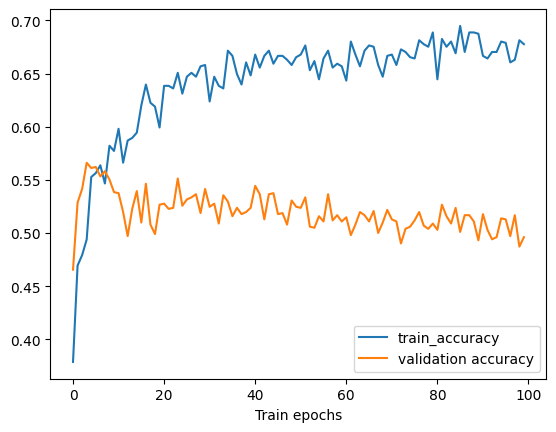

Training accuracy: 0.6777
Validation accuracy: 0.4961
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step
Classification report: 
               precision    recall  f1-score   support

           0       0.88      0.53      0.66       776
           1       0.20      0.34      0.25       155
           2       0.15      0.54      0.24        83

    accuracy                           0.50      1014
   macro avg       0.41      0.47      0.39      1014
weighted avg       0.72      0.50      0.57      1014



In [60]:
#Train FNN model with x_train under for multi class label
def train_and_evaluate(data='x_train_under multi',
                       hidden_layer_sizes=[10],
                       activation='relu',
                       optimizer='Adam',
                       learning_rate=0.01,
                       metric=tf.keras.metrics.SparseCategoricalAccuracy(),
                       num_epochs=100):

  # Build the model.
    model = build_model(n_classes=3,
                      hidden_layer_sizes=hidden_layer_sizes,
                      activation=activation,
                      optimizer=optimizer,
                      metric=metric,
                      learning_rate=learning_rate)


    X_train = x_train_under
    X_val = x_val
    Y_train = y_train_under
    Y_val = y_val['depression_severity']
    
  # Train the model.
    print('Training the', data, 'model...')
    history = model.fit(
        x=X_train,
        y=Y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_data=(X_val,Y_val),
        verbose=0
        )

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_accuracy = history.history['sparse_categorical_accuracy']
    val_accuracy = history.history['val_sparse_categorical_accuracy']
    plt.plot(train_accuracy, label='train_accuracy')
    plt.plot(val_accuracy, label='validation accuracy')
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()
    
    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    
    return model


# run the function
model = train_and_evaluate()
y_pred = np.argmax(model.predict(x_test), axis=1)
print(f'Classification report: \n {classification_report(y_test['depression_severity'], y_pred)}')

class_report = classification_report(y_test['depression_severity'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "FNN"
df_report['classification'] = "Multi (3)"
df_report['data_type'] = "x_train_under"
df_report_final = pd.concat([df_report_final, df_report])

Trial 30 Complete [00h 00m 02s]
val_sparse_categorical_accuracy: 0.7248520851135254

Best val_sparse_categorical_accuracy So Far: 0.7475345134735107
Total elapsed time: 00h 00m 44s

The hyperparameter search is complete. The optimal number of units in the first densely-connected
layer is 32 and the optimal learning rate for the optimizer
is 0.01.

Best epoch: 75
First 5 Learned Parameters: [[-0.7484331  -3.1323097  -1.1572514   0.45428    -1.4871358  -0.9409254
  -2.746673   -1.3851068  -0.2739619   0.81128067  1.2028216   1.0418719
  -0.06216955 -2.1333208  -0.9259174   0.953232    1.5178283  -1.7127631
   0.03551     1.0273931  -0.53362554  0.03167519 -2.2494466  -0.5287888
   1.6978724  -3.3019388  -1.7658931   0.54305404 -3.9243162   1.0191265
   0.29648212 -0.75098586]
 [-2.322906    0.01619253  0.5774422  -1.3434161  -0.23489018 -1.4826236
  -0.9517186  -0.2591507   0.4545961   0.64924365 -0.02417898 -1.2766799
   0.6493759  -0.13208869 -1.8616216  -0.5820237  -1.0779545  -0.9184

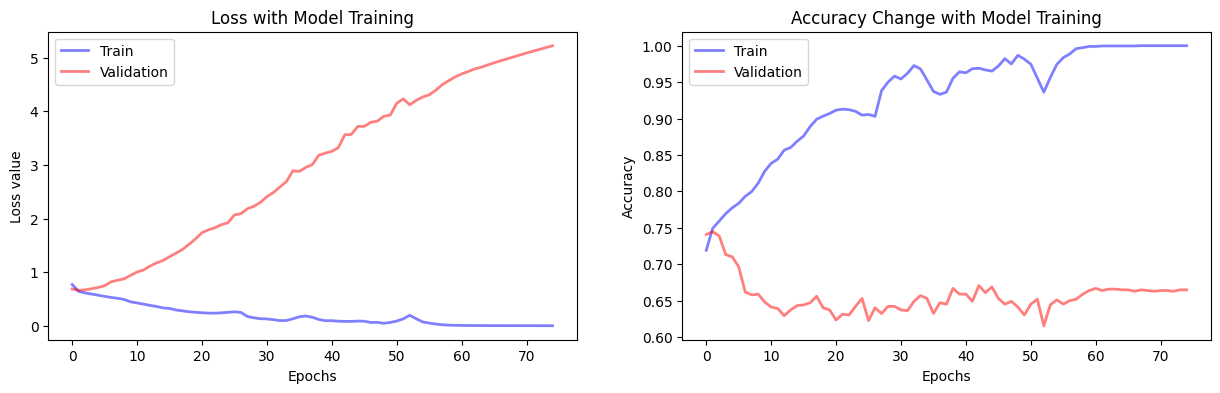

In [61]:
#Attempt to perform hpo with keras tuner using x_train data for multi class label
tf.random.set_seed(0)
tf.keras.utils.set_random_seed(0)
# YOUR CODE HERE
def build_model_tuner(hp):
  """Build a TF model using Keras that tunes hyperparameters.

  Args:
    hp: defines hyperparameters during model creation

  Returns:
    model: A tf.keras model (graph).
  """  
  model = tf.keras.Sequential()

  # Tune the number of units in the first Dense layer
  # Choose an optimal value between 32-512
  hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
  model.add(tf.keras.layers.Dense(units=hp_units, activation='relu',
                                  use_bias = True,
                                  bias_initializer = tf.ones_initializer)
                                  )
  model.add(tf.keras.layers.Dense(3, activation="softmax"))

  # Tune the learning rate for the optimizer
  # Choose an optimal value from 0.01, 0.001, or 0.0001
  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
  hp_units = hp.Int('units', min_value=32, max_value=512, step=32)

  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                loss='sparse_categorical_crossentropy',
                metrics=['sparse_categorical_accuracy'])

  return model
#perform tuning to determine high performing model
tuner = kt.Hyperband(build_model_tuner,
                     objective='val_sparse_categorical_accuracy',
                     max_epochs=10,
                     factor=3,
                     directory='my_dir',
                     project_name='HW_05',
                     overwrite = True)
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
tensorboard_callback = tf.keras.callbacks.TensorBoard("/home/jeff/Documents/Textbooks/DATASCI 207/Homework/my_dir/HW_04/tb_logs")
#Run search for optimal hyperparameters
tuner.search(
    x = x_train,
    y = y_train['depression_severity'],
    epochs = 50,
    validation_data=(x_val, y_val['depression_severity']),
    callbacks = [stop_early, tensorboard_callback]
)
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete. The optimal number of units in the first densely-connected
layer is {best_hps.get('units')} and the optimal learning rate for the optimizer
is {best_hps.get('learning_rate')}.
""")
# Build the model with the optimal hyperparameters and train it on the data for 100 epochs to find best number of epochs
model = tuner.hypermodel.build(best_hps)
history = model.fit(x_train, y_train['depression_severity'], epochs=100, validation_data=(x_val, y_val['depression_severity']), verbose=0)
val_acc_per_epoch = history.history['val_sparse_categorical_accuracy']
best_epoch = val_acc_per_epoch.index(min(val_acc_per_epoch)) + 1
# Retrain the model with chosen number of epochs
hypermodel = tuner.hypermodel.build(best_hps)
hypermodel.fit(x_train, y_train['depression_severity'], epochs=best_epoch, validation_data=(x_val, y_val['depression_severity']), verbose=0)
#Graph the loss and accuracy for this hypermodel
history_for_graph = hypermodel.history.history
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(history_for_graph['loss'], lw=2, color='blue', alpha = 0.5)
ax1.plot(history_for_graph['val_loss'], lw=2, color='red', alpha = 0.5)
ax1.legend(['Train', 'Validation'], fontsize=10)
ax1.set_xlabel('Epochs', size=10)
ax1.set_ylabel("Loss value")
ax1.set_title('Loss with Model Training')

ax2.plot(history_for_graph['sparse_categorical_accuracy'], lw=2, color='blue', alpha = 0.5)
ax2.plot(history_for_graph['val_sparse_categorical_accuracy'], lw=2, color='red', alpha = 0.5)
ax2.legend(['Train', 'Validation'], fontsize=10)
ax2.set_xlabel('Epochs', size=10)
ax2.set_ylabel("Accuracy")
ax2.set_title('Accuracy Change with Model Training')

print('Best epoch: %d' % (best_epoch,))
print(f'First 5 Learned Parameters: {hypermodel.layers[0].get_weights()[0][0:5]}\nBias Term: {hypermodel.layers[0].get_weights()[0][1]}')
print(f'Training Loss: {hypermodel.history.history["loss"][-1]} \n'
      f'Validation Loss: {hypermodel.history.history["val_loss"][-1]}')
print(f'Training loss/validation loss:{hypermodel.history.history["loss"][-1]/ 
                                                         hypermodel.history.history["val_loss"][-1]}')


In [62]:
#Create FNN model to be used for binary classification
def build_model_binary(n_classes,
                hidden_layer_sizes=[],
                activation='relu',
                optimizer='Adam',
                learning_rate=0.01,
                metric='metric'):
    """Build a multi-class logistic regression model using Keras.

    Args:
    n_classes: Number of output classes in the dataset.
    hidden_layer_sizes: A list with the number of units in each hidden layer.
    activation: The activation function to use for the hidden layers.
    optimizer: The optimizer to use (SGD, Adam).
    learning_rate: The desired learning rate for the optimizer.
    metric: The desired metric.

    Returns:
    model: A tf.keras model (graph).
    """
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    #This keras random seed is necessary for reproducibility- should have been added to function
    keras.utils.set_random_seed(0)

    # YOUR CODE HERE
    optimizer_dic = {"SGD": tf.keras.optimizers.SGD(learning_rate=learning_rate),
                     "Adam": tf.keras.optimizers.Adam(learning_rate=learning_rate)
                     }
    model = tf.keras.Sequential()
    j = 1
    model.add(tf.keras.Input(shape=(146,), name='Input'))
    for hidden_layer_size in hidden_layer_sizes:
        model.add(tf.keras.layers.Dense(units=hidden_layer_size,
                                        activation=activation,
                                        name=f'Hidden_{j}'))
        model.add(tf.keras.layers.Dropout(0.4, name=f'Dropout_{j}')) 
        j+=1
    model.add(tf.keras.layers.Dense(units=n_classes, activation='sigmoid', name='Output'))
    model.compile(
        optimizer=optimizer_dic[optimizer],
        loss='binary_crossentropy',
        metrics=[metric] 
    )


    return model

Training the x_train binary model...


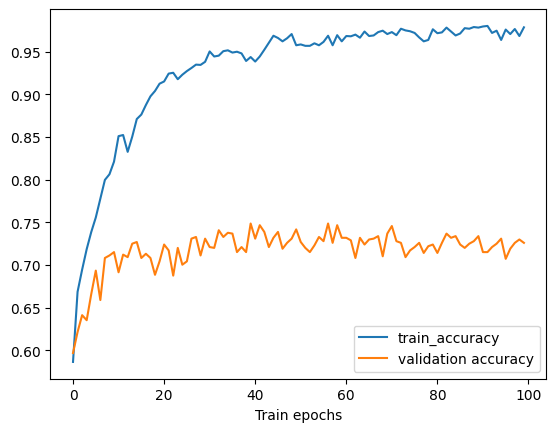

Training accuracy: 0.9786
Validation accuracy: 0.7258
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step
Classification report: 
               precision    recall  f1-score   support

           0       0.83      0.76      0.80       776
           1       0.39      0.50      0.44       238

    accuracy                           0.70      1014
   macro avg       0.61      0.63      0.62      1014
weighted avg       0.73      0.70      0.71      1014



In [63]:
#Train FNN model on x_train data for binary classification
class_weights_bin = {0:1, 1:4}
def train_and_evaluate_binary(data='x_train binary',
                       hidden_layer_sizes=[256],
                       activation='relu',
                       optimizer='Adam',
                       learning_rate=0.01,
                       metric=tf.keras.metrics.BinaryAccuracy(),
                       num_epochs=100):

  # Build the model.
    model = build_model_binary(n_classes=1,
                      hidden_layer_sizes=hidden_layer_sizes,
                      activation=activation,
                      optimizer=optimizer,
                      metric=metric,
                      learning_rate=learning_rate)


    X_train = x_train
    X_val = x_val
    Y_train = y_train['depression_sign_binary']
    Y_val = y_val['depression_sign_binary']
    
  # Train the model.
    print('Training the', data, 'model...')
    history = model.fit(
        x=X_train,
        y=Y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_data=(X_val,Y_val),
        verbose=0,
        class_weight = class_weights_bin
        )

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_accuracy = history.history['binary_accuracy']
    val_accuracy = history.history['val_binary_accuracy']
    plt.plot(train_accuracy, label='train_accuracy')
    plt.plot(val_accuracy, label='validation accuracy')
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()
    
    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    
    return model


# run the function
model = train_and_evaluate_binary()
y_pred = np.round(model.predict(x_test))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

class_report = classification_report(y_test['depression_sign_binary'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "FNN"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train"
df_report_final = pd.concat([df_report_final, df_report])

Training the x_train_under binary model...


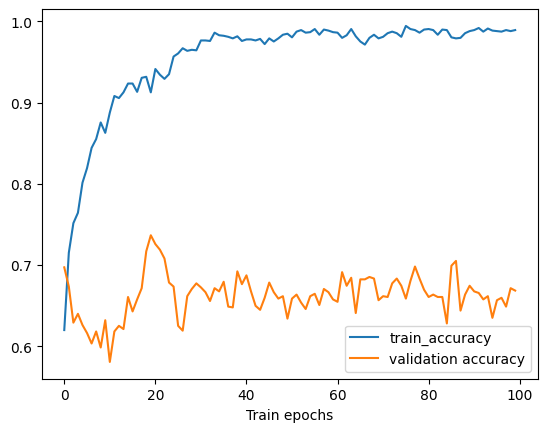

Training accuracy: 0.9891
Validation accuracy: 0.6686
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Classification report: 
               precision    recall  f1-score   support

           0       0.86      0.66      0.75       776
           1       0.37      0.65      0.47       238

    accuracy                           0.66      1014
   macro avg       0.61      0.65      0.61      1014
weighted avg       0.74      0.66      0.68      1014



In [64]:
#Train FNN model on x_train_under data for binary classification
def train_and_evaluate_binary(data='x_train_under binary',
                       hidden_layer_sizes=[256],
                       activation='relu',
                       optimizer='Adam',
                       learning_rate=0.01,
                       metric=tf.keras.metrics.BinaryAccuracy(),
                       num_epochs=100):

  # Build the model.
    model = build_model_binary(n_classes=1,
                      hidden_layer_sizes=hidden_layer_sizes,
                      activation=activation,
                      optimizer=optimizer,
                      metric=metric,
                      learning_rate=learning_rate)


    X_train = x_train_under_bin
    X_val = x_val
    Y_train = y_train_under_bin
    Y_val = y_val['depression_sign_binary']
    
  # Train the model.
    print('Training the', data, 'model...')
    history = model.fit(
        x=X_train,
        y=Y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_data=(X_val,Y_val),
        verbose=0
        )

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_accuracy = history.history['binary_accuracy']
    val_accuracy = history.history['val_binary_accuracy']
    plt.plot(train_accuracy, label='train_accuracy')
    plt.plot(val_accuracy, label='validation accuracy')
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()
    
    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    
    return model


# run the function
model = train_and_evaluate_binary()
y_pred = np.round(model.predict(x_test))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

class_report = classification_report(y_test['depression_sign_binary'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "FNN"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train_under"
df_report_final = pd.concat([df_report_final, df_report])

Training the digits model...


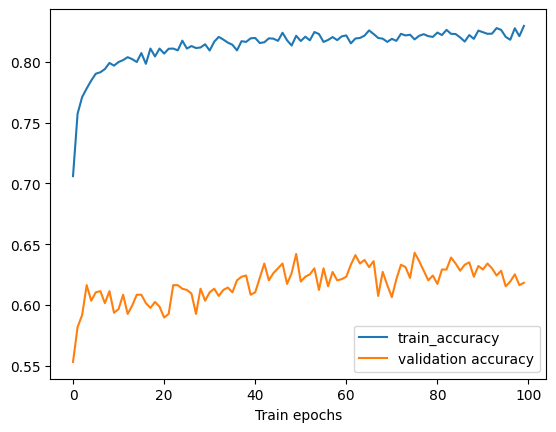

Training accuracy: 0.8294
Validation accuracy: 0.6183
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step
Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.55      0.67       776
           1       0.33      0.74      0.46       238

    accuracy                           0.59      1014
   macro avg       0.60      0.64      0.57      1014
weighted avg       0.75      0.59      0.62      1014



In [65]:
#Train FNN model on x_train_bal (upscaled) data for binary classification
def train_and_evaluate_binary(data='digits',
                       hidden_layer_sizes=[10],
                       activation='relu',
                       optimizer='Adam',
                       learning_rate=0.01,
                       metric=tf.keras.metrics.BinaryAccuracy(),
                       num_epochs=100):

  # Build the model.
    model = build_model_binary(n_classes=1,
                      hidden_layer_sizes=hidden_layer_sizes,
                      activation=activation,
                      optimizer=optimizer,
                      metric=metric,
                      learning_rate=learning_rate)


    X_train = x_train_bal
    X_val = x_val
    Y_train = y_train_bal['depression_sign_binary']
    Y_val = y_val['depression_sign_binary']
    
  # Train the model.
    print('Training the', data, 'model...')
    history = model.fit(
        x=X_train,
        y=Y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_data=(X_val,Y_val),
        verbose=0
        )

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_accuracy = history.history['binary_accuracy']
    val_accuracy = history.history['val_binary_accuracy']
    plt.plot(train_accuracy, label='train_accuracy')
    plt.plot(val_accuracy, label='validation accuracy')
    plt.xlabel('Train epochs')
    plt.legend()
    plt.show()
    
    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    
    return model


# run the function
model = train_and_evaluate_binary()
y_pred = np.round(model.predict(x_test))
print(f'Classification report: \n {classification_report(y_test['depression_sign_binary'], y_pred)}')

class_report = classification_report(y_test['depression_sign_binary'], y_pred, output_dict=True)
df_report = pd.DataFrame(class_report).transpose()
df_report['model'] = "FNN"
df_report['classification'] = "Binary"
df_report['data_type'] = "x_train_bal"
df_report_final = pd.concat([df_report_final, df_report])

In [66]:
df_report_final.to_csv('classification_report_final.csv', index=True)

In [67]:
df_report_final

,precision,recall,f1-score,support,model,classification,data_type
0,0.806277,0.960052,0.876471,776.000000,Logistic Regression,Multi (3),x_train
1,0.362069,0.135484,0.197183,155.000000,Logistic Regression,Multi (3),x_train
2,0.312500,0.120482,0.173913,83.000000,Logistic Regression,Multi (3),x_train
accuracy,0.765286,0.765286,0.765286,0.765286,Logistic Regression,Multi (3),x_train
macro avg,0.493615,0.405339,0.415856,1014.000000,Logistic Regression,Multi (3),x_train
...,...,...,...,...,...,...,...
0,0.872690,0.547680,0.673001,776.000000,FNN,Binary,x_train_bal
1,0.333966,0.739496,0.460131,238.000000,FNN,Binary,x_train_bal
accuracy,0.592702,0.592702,0.592702,0.592702,FNN,Binary,x_train_bal
macro avg,0.603328,0.643588,0.566566,1014.000000,FNN,Binary,x_train_bal


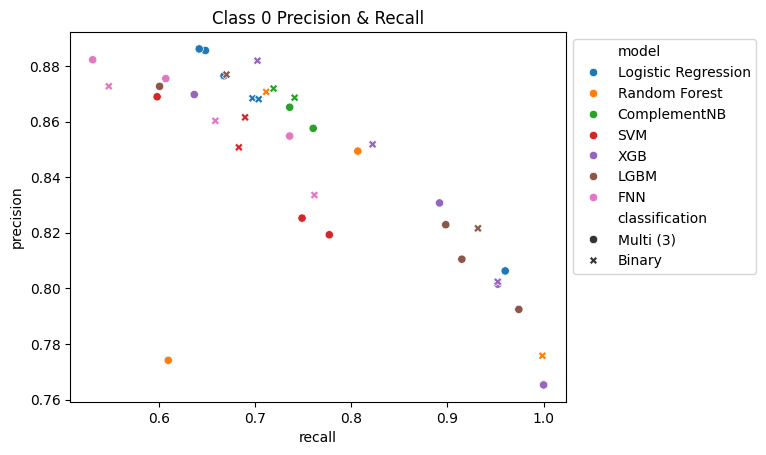

In [68]:
#Create scatterplot for class 0 precision/recall of different models
ax = sns.scatterplot(data=df_report_final.filter(like='0', axis=0), x='recall', y='precision', hue='model', style='classification')
plt.title("Class 0 Precision & Recall")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

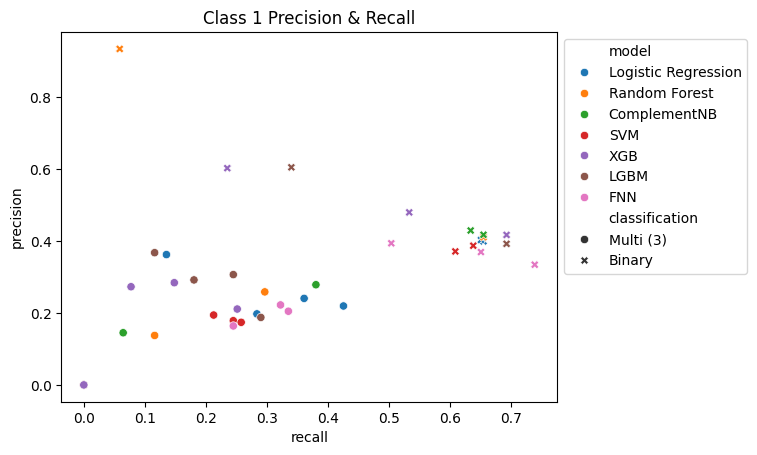

In [69]:
#Create scatterplot for class 1 precision/recall of different models- Note that in binary models class 1 represents both mild and severe depression
ax = sns.scatterplot(data=df_report_final.filter(like='1', axis=0), x='recall', y='precision', hue='model', style='classification')
plt.title("Class 1 Precision & Recall")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

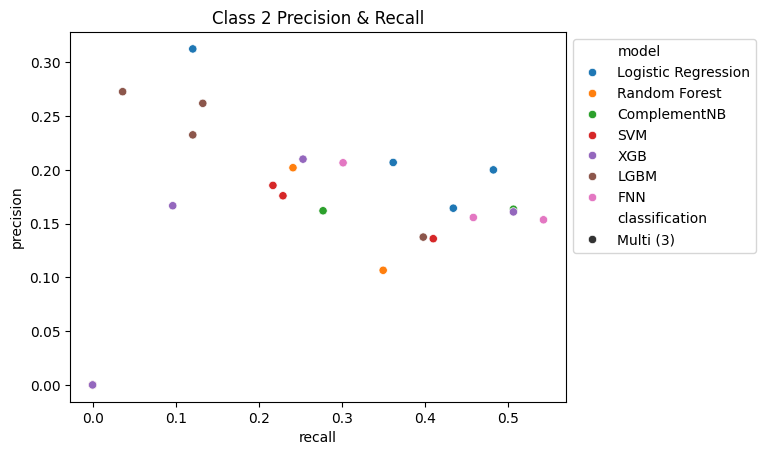

In [70]:
#Create scatterplot for class 2 precision/recall of different models- Note that this class only exists in multi classification
ax = sns.scatterplot(data=df_report_final.filter(like='2', axis=0), x='recall', y='precision', hue='model', style='classification')
plt.title("Class 2 Precision & Recall")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

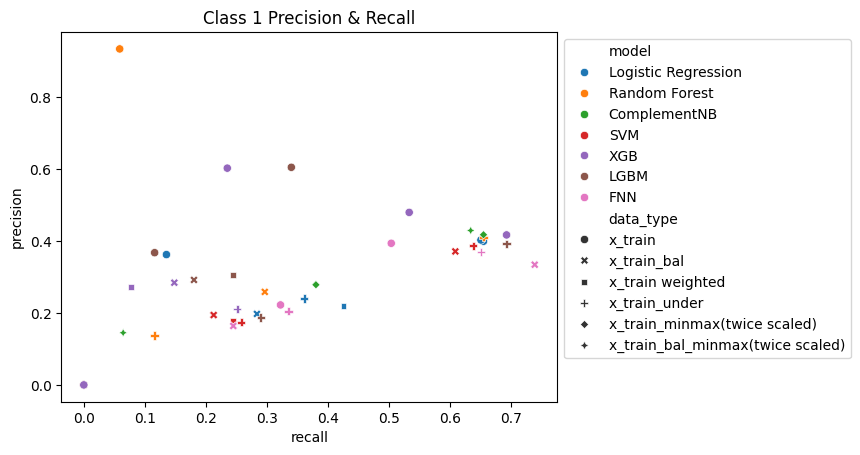

In [71]:
#Create scatterplot for class 1 precision/recall of different models with focus on data types instead of classification method
ax = sns.scatterplot(data=df_report_final.filter(like='1', axis=0), x='recall', y='precision', hue='model', style='data_type')
plt.title("Class 1 Precision & Recall")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()